Imports

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import re
import sys
import os
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
from dotenv import load_dotenv
from pathlib import Path


In [ ]:


PATH_SEP = os.sep

# Merging the path

sys.path.append(os.path.abspath('../../'))

# 1. Load the .env file
load_dotenv()

folder_path = os.getenv("EXTERNAL_DATA_FOLDER")
dir_files=os.listdir(folder_path)

# Creating File Paths
files=[]
for file in dir_files:
    files.append(folder_path+PATH_SEP+file)

files=sorted(files)

print(files)
# Reading Data
knn=pd.read_csv(files[1])

# KNeighborsClassifier

In [ ]:
leaky_features = [
    "Prospect_Outcome",
    "renewal_decision_bin",
    "Total_Renewal_Score_New",
    "agent_confirmation___acceptance___agreement",
    "agent_initiated_renewal_flag",
    "crm_customer_payment_intention"
]

logreg = logreg.drop(columns=[f for f in leaky_features if f in logreg.columns])

In [ ]:
# 1. Split
X = knn.drop('churn', axis=1)
y = knn['churn']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:

# 2. Grid Search

param_grid = {'n_neighbors': range(1, 21)}
cv = StratifiedKFold(n_splits=5)

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=cv, scoring='roc_auc')
grid.fit(X_train, y_train)

print("Best K:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best K: {'n_neighbors': 20}
Best CV Score: 0.9866801592183533


In [ ]:

# 3. Best Model
best_knn = grid.best_estimator_

In [ ]:

# 4. Evaluate

#y_pred = best_knn.predict(X_test)
y_prob = best_knn.predict_proba(X_test)[:, 1]

for t in [0.2, 0.3, 0.4, 0.5]:
    y_pred_t = (y_prob > t).astype(int)
    print(f"\nThreshold: {t}")

    print("\nAccuracy:", accuracy_score(y_test, y_pred_t))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_t))
    print("\nClassification Report:\n", classification_report(y_test, y_pred_t))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Threshold: 0.2

Accuracy: 0.9663783482142857

Confusion Matrix:
 [[5623  163]
 [  78 1304]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98      5786
           1       0.89      0.94      0.92      1382

    accuracy                           0.97      7168
   macro avg       0.94      0.96      0.95      7168
weighted avg       0.97      0.97      0.97      7168


Threshold: 0.3

Accuracy: 0.9669363839285714

Confusion Matrix:
 [[5663  123]
 [ 114 1268]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      5786
           1       0.91      0.92      0.91      1382

    accuracy                           0.97      7168
   macro avg       0.95      0.95      0.95      7168
weighted avg       0.97      0.97      0.97      7168


Threshold: 0.4

Accuracy: 0.9654017857142857

Confusion Matrix:
 [[5678  108]
 [ 140 1242]]

Classification R

| Threshold | Precision (Churn) | Recall (Churn) | FN (Missed churn) | FP  |
| --------- | ----------------- | -------------- | ----------------- | --- |
| 0.2       | 0.89              | 0.94           | 78                | 163
| 0.3       | 0.91              | 0.92           | 114               | 123 |
| 0.4       | 0.92              | 0.90           | 140               | 108 |
| 0.5       | 0.93              | 0.87           | 173               | 89  |


We optimized the KNN model using ROC‑AUC and subsequently tuned the decision threshold to balance churn detection and operational cost. At a threshold of 0.3, the model achieves a strong trade‑off between precision and recall, capturing approximately 92% of churn customers while maintaining high precision (91%) and overall accuracy (97%). This threshold significantly reduces missed churn cases without generating an excessive number of false positives, making it well‑suited for business scenarios where early churn identification is critical but retention efforts still carry a moderate cost.

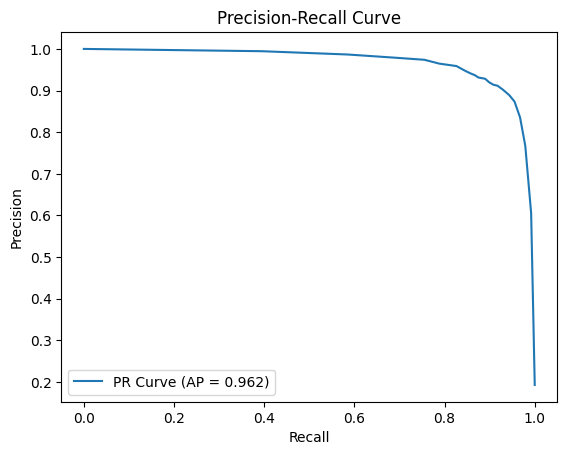

In [ ]:
# Compute curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
# Average Precision (AUC for PR curve)
ap_score = average_precision_score(y_test, y_prob)

# Plot
plt.figure()
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# Logistic Regression

In [ ]:
logreg=pd.read_csv(files[1])

Drop leaky features

In [ ]:
leaky_features = [
    "Prospect_Outcome",
    "renewal_decision_bin",
    "Total_Renewal_Score_New",
    "agent_confirmation___acceptance___agreement",
    "agent_initiated_renewal_flag",
    "crm_customer_payment_intention"
]

logreg = logreg.drop(columns=[f for f in leaky_features if f in logreg.columns])

Feature / Target Split, Train–Test Split (Stratified)

In [ ]:
# 1. Split
X = logreg.drop('churn', axis=1)
y = logreg['churn']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Train Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# log_model = LogisticRegression(max_iter=1000)
log_model = LogisticRegression(max_iter=1000, class_weight='balanced',solver="liblinear")

log_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')

Predictions

In [ ]:
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

Evaluation (Default Threshold = 0.5)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
# default threshold 0.5

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Accuracy: 0.8479352678571429

Confusion Matrix:
 [[4934  852]
 [ 238 1144]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.85      0.90      5786
           1       0.57      0.83      0.68      1382

    accuracy                           0.85      7168
   macro avg       0.76      0.84      0.79      7168
weighted avg       0.88      0.85      0.86      7168

ROC-AUC: 0.9084654910825721


 Custom Threshold

In [ ]:

threshold = 0.3
y_pred_custom = (y_prob > threshold).astype(int)

print(f"\nResults at Threshold = {threshold}")
print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_custom))
print("\nClassification Report:\n", classification_report(y_test, y_pred_custom))



Results at Threshold = 0.3
Accuracy: 0.7356305803571429

Confusion Matrix:
 [[4032 1754]
 [ 141 1241]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.70      0.81      5786
           1       0.41      0.90      0.57      1382

    accuracy                           0.74      7168
   macro avg       0.69      0.80      0.69      7168
weighted avg       0.86      0.74      0.76      7168



 Precision–Recall Curve

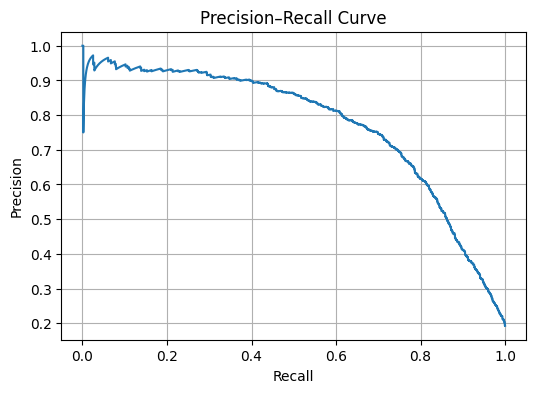

In [ ]:
import pandas as pd
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid()
plt.show()


Feature Importance

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print("\nTop features increasing churn:")
print(feature_importance.head(10))

print("\nTop features reducing churn:")
print(feature_importance.tail(10))


Top features increasing churn:
                                             Feature  Coefficient
23        agent_cancellation___termination___closure     1.746315
33                                      Tenure_Years     1.541063
16                                       desire_code     1.141893
48                              days_since_last_call     0.952140
0                                          log_calls     0.849744
25                          agent_customer_retention     0.776733
40                              discount_interaction     0.740824
21             agent_accreditation_and_certification     0.566639
20                                    reaction_other     0.541980
17  reaction_clarification___justification___inquiry     0.493858

Top features reducing churn:
                                 Feature  Coefficient
13                 serious_complaint_bin    -0.458565
45                serious_complaint_flag    -0.458565
6                            recognition    -0.517

# Support vector machine

In [ ]:
svm=pd.read_csv(files[1])

In [3]:
leaky_features = [
    "Prospect_Outcome",
    "renewal_decision_bin",
    "Total_Renewal_Score_New",
    "agent_confirmation___acceptance___agreement",
    "agent_initiated_renewal_flag",
    "crm_customer_payment_intention"
]

svm = svm.drop(columns=[f for f in leaky_features if f in svm.columns])

In [ ]:

X = svm.drop("churn", axis=1)
y = svm["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Linear svm

In [ ]:
param_grid_linear = {
    "C": [0.01, 0.1, 1, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_linear = GridSearchCV(
    SVC(
        kernel="linear",
        probability=True,
        class_weight="balanced"
    ),
    param_grid=param_grid_linear,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

grid_linear.fit(X_train, y_train)

print("Best Linear SVM Params:", grid_linear.best_params_)
print("Best Linear SVM CV ROC-AUC:", grid_linear.best_score_)

In [ ]:
best_linear_svm = grid_linear.best_estimator_

y_prob_linear = best_linear_svm.predict_proba(X_test)[:, 1]

In [ ]:
for t in [0.2, 0.3, 0.4, 0.5]:
    y_pred_t = (y_prob_linear > t).astype(int)

    print(f"\nLinear SVM - Threshold {t}")
    print("Accuracy:", accuracy_score(y_test, y_pred_t))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_t))
    print("Classification Report:\n", classification_report(y_test, y_pred_t))

In [ ]:
print("Linear SVM ROC-AUC:", roc_auc_score(y_test, y_prob_linear))

RBF SVM (NON‑LINEAR)

In [ ]:
param_grid_rbf = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.1]
}

grid_rbf = GridSearchCV(
    SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced"
    ),
    param_grid=param_grid_rbf,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

grid_rbf.fit(X_train, y_train)

print("Best RBF SVM Params:", grid_rbf.best_params_)
print("Best RBF SVM CV ROC-AUC:", grid_rbf.best_score_)

In [ ]:
best_rbf_svm = grid_rbf.best_estimator_

y_prob_rbf = best_rbf_svm.predict_proba(X_test)[:, 1]

In [ ]:
for t in [0.2, 0.3, 0.4, 0.5]:
    y_pred_t = (y_prob_rbf > t).astype(int)

    print(f"\nRBF SVM – Threshold {t}")
    print("Accuracy:", accuracy_score(y_test, y_pred_t))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_t))
    print("Classification Report:\n", classification_report(y_test, y_pred_t))

In [ ]:
print("RBF SVM ROC-AUC:", roc_auc_score(y_test, y_prob_rbf))


In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_rbf)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("SVM (RBF) Precision–Recall Curve")
plt.grid()
plt.show()
